# Multiple Experiment Plots

In [1]:
import numpy as np
import os
import torch 
import torch.distributions as dists
from matplotlib import pyplot as plt
from scipy import stats
import sys
# Add parent directory of this file to path
sys.path.append(os.path.dirname(os.path.abspath('')))
from MSM.utils import data as utils
from MSM.utils import exact_KL, exact_score_loss
from MSM.utils.data import get_ci  # noqa: E402

data_path = os.path.join(os.path.pardir,"simulated_data", "NormalEstimation")

plt.rc('font',**{'family':'sans-serif'})
#If fonttype = 1 doesn't work with LaTeX, try fonttype 42.
plt.rc('pdf',fonttype = 42)
plt.rc('ps',fonttype = 42)
plt.rcParams['figure.dpi'] = 140


# Strong Connection High Dimensional Experiment

In [2]:
# Read in data
sample_sizes = [200, 400, 600, 800, 1000]
save_path = os.path.join(os.path.pardir,"simulated_data", "NormalEstimation","10DimStrongConnection","VarySampleSize")
methods = ["iw", "em", "variational", "missdiff", "variationaltrunc"]
names = ["Marg-IW (Ours)", "EM", "Marg-Var (Ours)", "Zeroed", "Marg-Var (Ours)"]
name_dict = dict(zip(methods, names))
mean_dists = {method: [] for method in methods}
prec_dists = {method: [] for method in methods}
score_losses = {method: [] for method in methods}
kl_losses = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in methods:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for sample_size in sample_sizes:
        data = torch.load(os.path.join(save_path,f"{method}_varyn_n={sample_size}.pt"),weights_only=True)
        temp_mean = utils.recursive_tensorize(data["Means"])
        temp_prec = utils.recursive_tensorize(data["Precisions"])
        temp_true_mean = utils.recursive_tensorize(data["True Mean"])
        temp_true_cov = utils.recursive_tensorize(data["True Covariance"])

        mean_dists[method].append(torch.linalg.norm(temp_mean-temp_true_mean, dim=-1))
        prec_dists[method].append(torch.linalg.matrix_norm(temp_prec-torch.linalg.inv(temp_true_cov)))
        score_losses[method].append(exact_score_loss(temp_true_mean, temp_mean, temp_true_cov, temp_prec, give_prec=True))
        kl_losses[method].append(exact_KL(temp_true_mean, temp_mean, temp_true_cov, temp_prec, give_prec=True))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors
    print(method)
    est_precs = utils.recursive_tensorize(temp_prec)

    est_means = utils.recursive_tensorize(temp_mean)
    true_mean = utils.recursive_tensorize(temp_true_mean)
    true_cov = utils.recursive_tensorize(temp_true_cov)
    
    # Get distances

# Combine errors into dict
errors = [mean_dists, prec_dists, score_losses, kl_losses, losses]
ylabs = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence", "Losses"]
errors_dict = dict(zip(ylabs, errors))


iw
em
variational
missdiff
variationaltrunc


tensor(199)
tensor(199)
tensor(200)
tensor(200)
tensor(200)


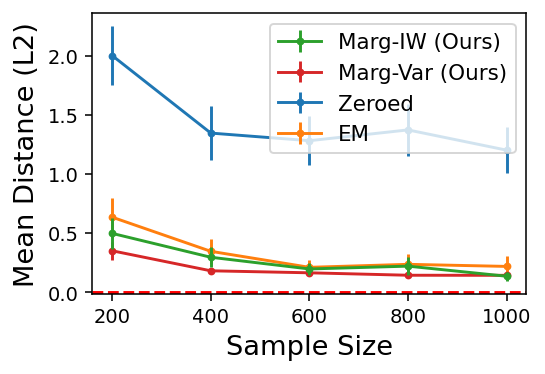

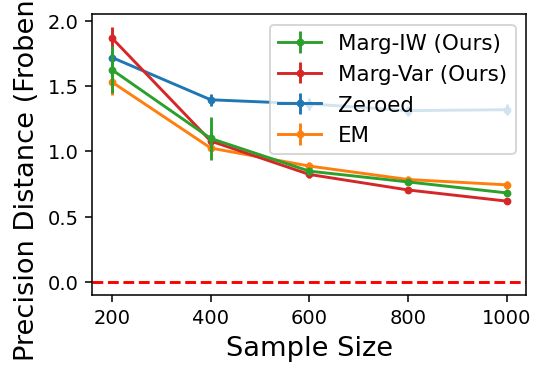

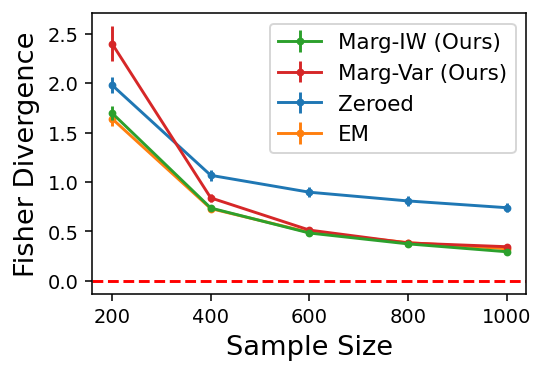

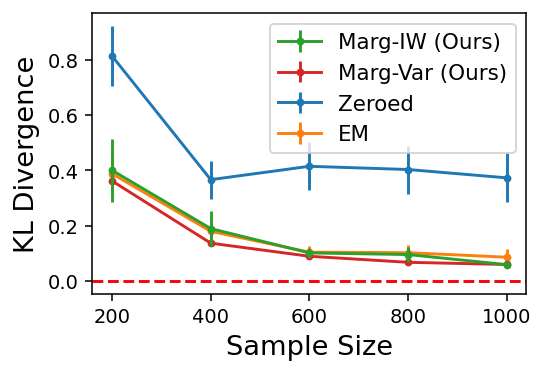

In [3]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence"]
plot_methods = ["iw", "variationaltrunc", "missdiff", "em" ]
colours = ["C2", "C3","C0","C1"]
for err_name in plot_errors:
    fig, ax = plt.subplots(figsize=(4, 2.6))
    for i, method in enumerate(plot_methods):
        temp_list = []
        for j in range(len(sample_sizes)):
            data = errors_dict[err_name][method][j]
            losses = errors_dict["Losses"][method][j]
            if (err_name=="Fisher Divergence") & (method=="iw"):
                print(torch.sum(data<20))

            data = data[data<20]
            temp_list.append(get_ci(data, dim=-1).detach().clone())
        dist_cis = torch.stack(temp_list, dim=-1)
        ax.errorbar(sample_sizes, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                    label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
    ax.legend(fontsize=11)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Sample Size", fontsize=14)
    ax.set_ylabel(err_name, fontsize=14)
    fig.savefig(f"../plots/NormalEstimation/{err_name}_10dim_randomcov.pdf", bbox_inches="tight")

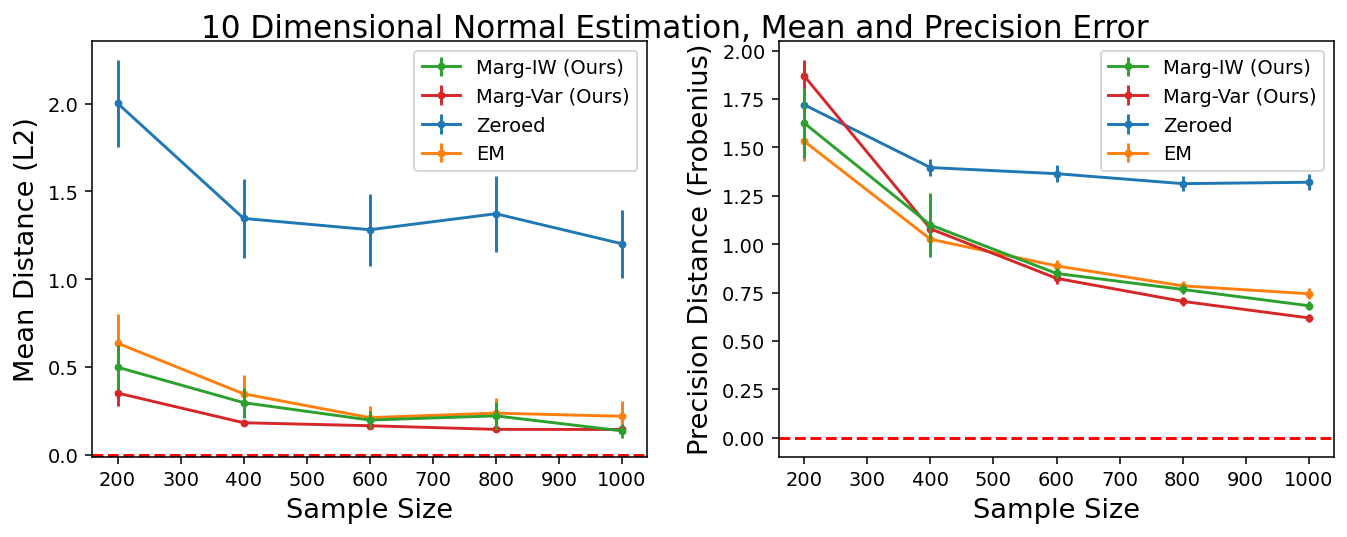

In [4]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)",]
# plot_methods = ["marg2_iw", "marginal_mle", "em_iw", "marg_vardiagreg", "marg_vardiagiwreg",
#                 "marg_varexact", "marg_varconst", "marg_varconstiw"]
plot_methods = ["iw", "variationaltrunc", "missdiff", "em" ]
colours = ["C2", "C3","C0","C1", "C4"]
fig, axs = plt.subplots(figsize=(10, 4), ncols=2)
for k,err_name in enumerate(plot_errors):
    for i, method in enumerate(plot_methods):
        # if method == "variational":
        #     continue
        # Get confidence intervals
        temp_list = []
        for j in range(len(sample_sizes)):
            data = errors_dict[err_name][method][j]
            losses = errors_dict["Losses"][method][j]
            if (err_name=="Fisher Divergence") & (method=="iw"):
                print(torch.sum(data<20))

            data = data[data<20]
            temp_list.append(get_ci(data, dim=-1).detach().clone())
            # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1))
        # dist_cis = torch.stack([torch.nanquantile(errors_dict[err_name][method][i], torch.tensor([0.5,0.25,0.75]), dim=-1) for i in range(len(sample_sizes))],dim=-1)
        dist_cis = torch.stack(temp_list, dim=-1)
        axs[k].errorbar(sample_sizes, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                    label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
        # if err_name =="Fisher Divergence":
        #     ax.set_ylim(0, 2.5)
    axs[k].legend()
    axs[k].axhline(0, color="red", linestyle="--")
    axs[k].set_xlabel("Sample Size", fontsize=14)
    axs[k].set_ylabel(err_name, fontsize=14)

fig.tight_layout(pad=2.0)
fig.suptitle("10 Dimensional Normal Estimation, Mean and Precision Error", fontsize=16)
fig.savefig(f"../plots/NormalEstimation/meanandprecision_10dim_randomcov.pdf", bbox_inches="tight")

# Strong Connection Truncated High-Dim Experiment

In [5]:
# Read in data
sample_sizes = [200, 400, 600, 800, 1000]
save_path = os.path.join(os.path.pardir,"simulated_data", "NormalEstimation","10DimStrongConnectionTruncated","VarySampleSize")
methods = ["iw", "em", "variational", "missdiff"]
names = ["Marg-IW (Ours)", "EM", "Marg-Var (Ours)", "Zeroed"]
name_dict = dict(zip(methods, names))
mean_dists = {method: [] for method in methods}
prec_dists = {method: [] for method in methods}
score_losses = {method: [] for method in methods}
kl_losses = {method: [] for method in methods}
losses = {method: [] for method in methods}
for method in methods:
    temp_mean = []
    temp_true_mean = []
    temp_prec = []
    temp_true_cov = []
    # Get samples
    for sample_size in sample_sizes:
        data = torch.load(os.path.join(save_path,f"{method}_varyn_n={sample_size}.pt"),weights_only=True)
        temp_mean = utils.recursive_tensorize(data["Means"])
        temp_prec = utils.recursive_tensorize(data["Precisions"])
        temp_true_mean = utils.recursive_tensorize(data["True Mean"])
        temp_true_cov = utils.recursive_tensorize(data["True Covariance"])

        mean_dists[method].append(torch.linalg.norm(temp_mean-temp_true_mean, dim=-1))
        prec_dists[method].append(torch.linalg.matrix_norm(temp_prec-torch.linalg.inv(temp_true_cov)))
        score_losses[method].append(exact_score_loss(temp_true_mean, temp_mean, temp_true_cov, temp_prec, give_prec=True))
        kl_losses[method].append(exact_KL(temp_true_mean, temp_mean, temp_true_cov, temp_prec, give_prec=True))
        losses[method].append(utils.recursive_tensorize(data["Losses"]))
    # Combine into tensors
    print(method)
    est_precs = utils.recursive_tensorize(temp_prec)

    est_means = utils.recursive_tensorize(temp_mean)
    true_mean = utils.recursive_tensorize(temp_true_mean)
    true_cov = utils.recursive_tensorize(temp_true_cov)
    
    # Get distances

# Combine errors into dict
errors = [mean_dists, prec_dists, score_losses, kl_losses, losses]
ylabs = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence", "Losses"]
errors_dict = dict(zip(ylabs, errors))


iw
em
variational
missdiff


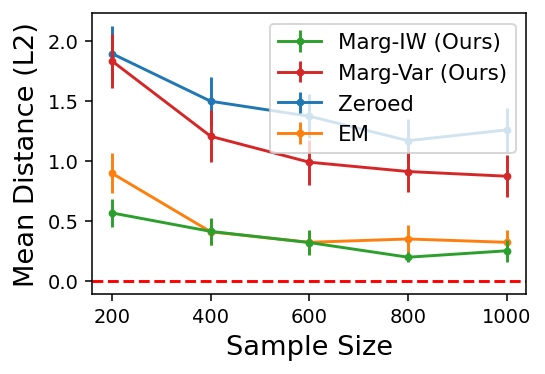

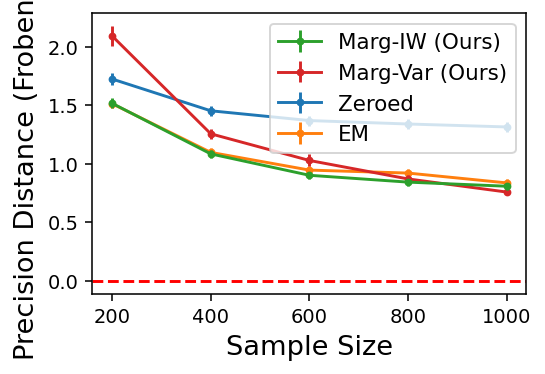

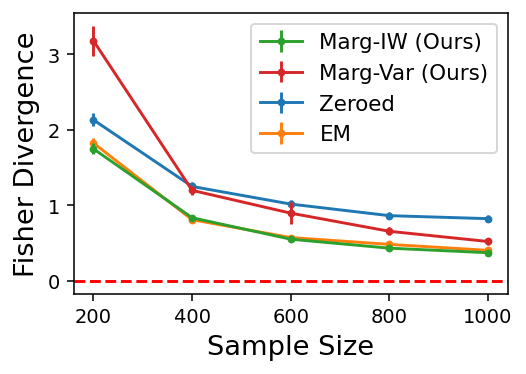

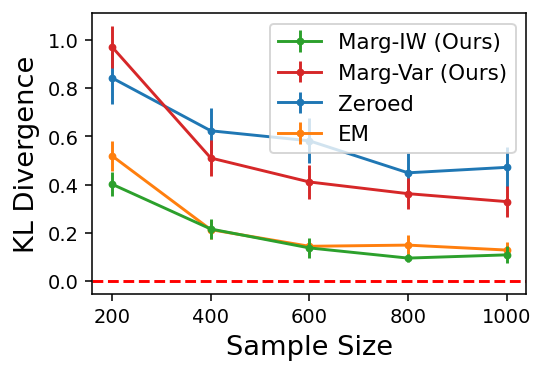

In [6]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)","Fisher Divergence", "KL Divergence"]
# plot_methods = ["marg2_iw", "marginal_mle", "em_iw", "marg_vardiagreg", "marg_vardiagiwreg",
#                 "marg_varexact", "marg_varconst", "marg_varconstiw"]
plot_methods = ["iw", "variational", "missdiff", "em"    ]
colours = ["C2", "C3","C0","C1"]
for err_name in plot_errors:
    fig, ax = plt.subplots(figsize=(4, 2.6))
    for i, method in enumerate(plot_methods):
        temp_list = []
        for j in range(len(sample_sizes)):
            data = errors_dict[err_name][method][j]
            data = data[data<20]
            losses = errors_dict["Losses"][method][j]
            temp_list.append(get_ci(data, dim=-1).detach().clone())
        dist_cis = torch.stack(temp_list, dim=-1)
        ax.errorbar(sample_sizes, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                    label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
    ax.legend(fontsize=11)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Sample Size", fontsize=14)
    ax.set_ylabel(err_name, fontsize=14)
    fig.savefig(f"../plots/NormalEstimation/{err_name}_trunc10dim_randomcov.pdf", bbox_inches="tight")

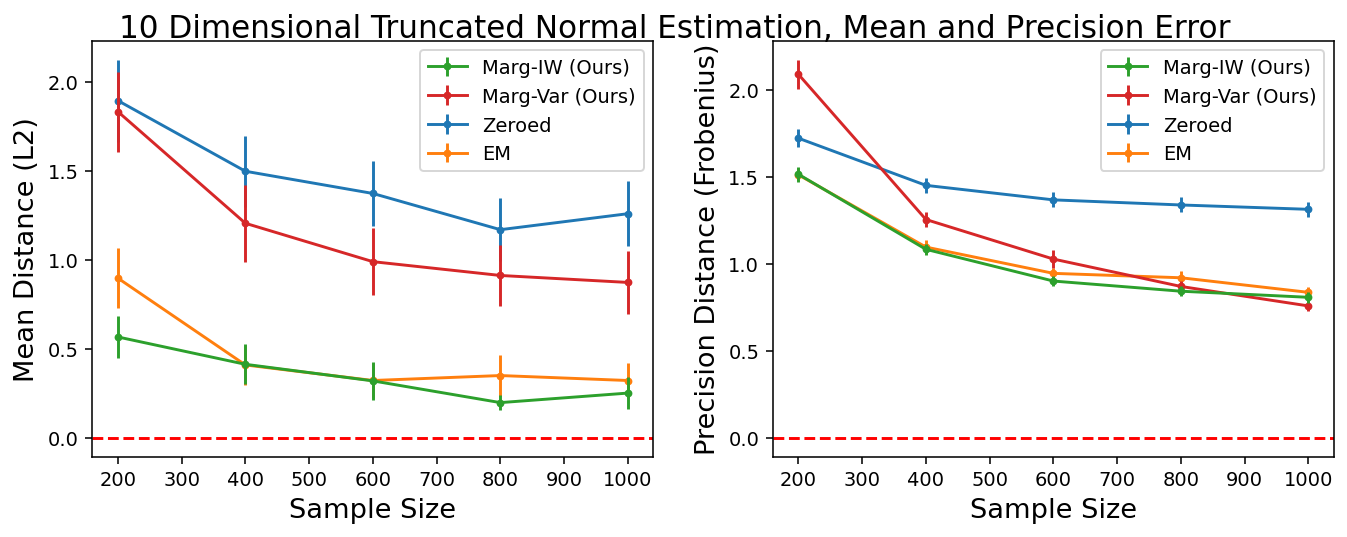

In [7]:
plot_errors = ["Mean Distance (L2)", "Precision Distance (Frobenius)",]
# plot_methods = ["marg2_iw", "marginal_mle", "em_iw", "marg_vardiagreg", "marg_vardiagiwreg",
#                 "marg_varexact", "marg_varconst", "marg_varconstiw"]
plot_methods = ["iw", "variational", "missdiff", "em" ]
colours = ["C2", "C3","C0","C1", "C4"]
fig, axs = plt.subplots(figsize=(10, 4), ncols=2)
for k,err_name in enumerate(plot_errors):
    for i, method in enumerate(plot_methods):
        # if method == "variational":
        #     continue
        # Get confidence intervals
        temp_list = []
        for j in range(len(sample_sizes)):
            data = errors_dict[err_name][method][j]
            losses = errors_dict["Losses"][method][j]
            if (err_name=="Fisher Divergence") & (method=="iw"):
                print(torch.sum(data<20))

            data = data[data<20]
            temp_list.append(get_ci(data, dim=-1).detach().clone())
            # temp_list.append(torch.nanquantile(data, torch.tensor([0.5,0.25,0.75]), dim=-1))
        # dist_cis = torch.stack([torch.nanquantile(errors_dict[err_name][method][i], torch.tensor([0.5,0.25,0.75]), dim=-1) for i in range(len(sample_sizes))],dim=-1)
        dist_cis = torch.stack(temp_list, dim=-1)
        axs[k].errorbar(sample_sizes, dist_cis[0], yerr=dist_cis[0]-dist_cis[1],
                    label=name_dict[method], fmt="-o",alpha=1, markersize=3, color=colours[i], zorder=5-i)
        # if err_name =="Fisher Divergence":
        #     ax.set_ylim(0, 2.5)
    axs[k].legend()
    axs[k].axhline(0, color="red", linestyle="--")
    axs[k].set_xlabel("Sample Size", fontsize=14)
    axs[k].set_ylabel(err_name, fontsize=14)

fig.tight_layout(pad=2.0)
fig.suptitle("10 Dimensional Truncated Normal Estimation, Mean and Precision Error", fontsize=16)
fig.savefig(f"../plots/NormalEstimation/meanandprecision_10dimtrunc_randomcov.pdf", bbox_inches="tight")

# Plot Marginalisations

9141
tensor([[ 1.7598e+00,  9.2780e-02,  1.3381e-01, -1.4057e-02,  1.8050e-01,
          4.3729e-02, -1.7659e-02,  1.1252e-02, -9.9142e-02, -1.7174e+00],
        [ 9.2780e-02,  9.7977e-01,  1.3168e-01,  7.1748e-02,  1.9827e-01,
          4.9008e-02, -7.7329e-02,  1.0440e-01, -1.4732e-01,  0.0000e+00],
        [ 1.3381e-01,  1.3168e-01,  1.3959e+00, -4.8496e-02,  3.3131e-01,
          1.1596e-01, -3.8028e-02, -1.9114e-01, -2.7559e-01,  0.0000e+00],
        [-1.4057e-02,  7.1748e-02, -4.8496e-02,  1.2204e+00,  4.4141e-02,
         -1.5352e-01, -2.4277e-01,  2.0165e-01, -1.2669e-01,  0.0000e+00],
        [ 1.8050e-01,  1.9827e-01,  3.3131e-01,  4.4141e-02,  1.0969e+00,
          1.4526e-01, -9.9336e-02, -8.6779e-02, -1.3634e-01,  0.0000e+00],
        [ 4.3729e-02,  4.9008e-02,  1.1596e-01, -1.5352e-01,  1.4526e-01,
          1.0080e+00,  2.9916e-02, -1.6281e-01,  9.8345e-02,  0.0000e+00],
        [-1.7659e-02, -7.7329e-02, -3.8028e-02, -2.4277e-01, -9.9336e-02,
          2.9916e-02,  8.97

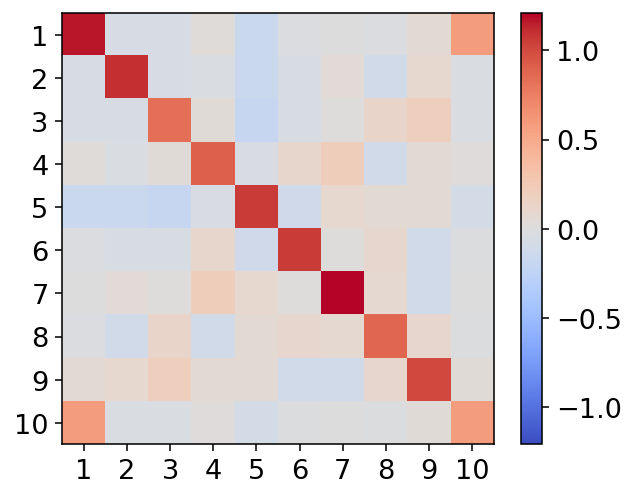

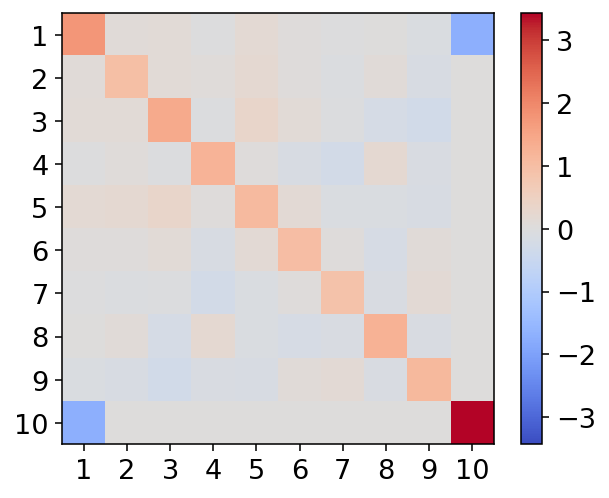

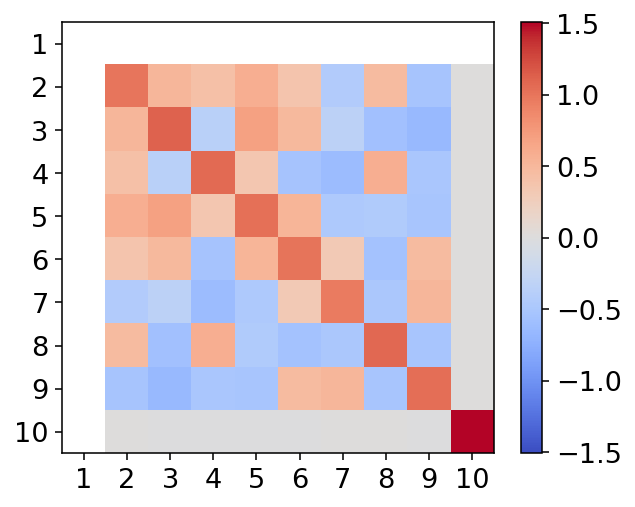

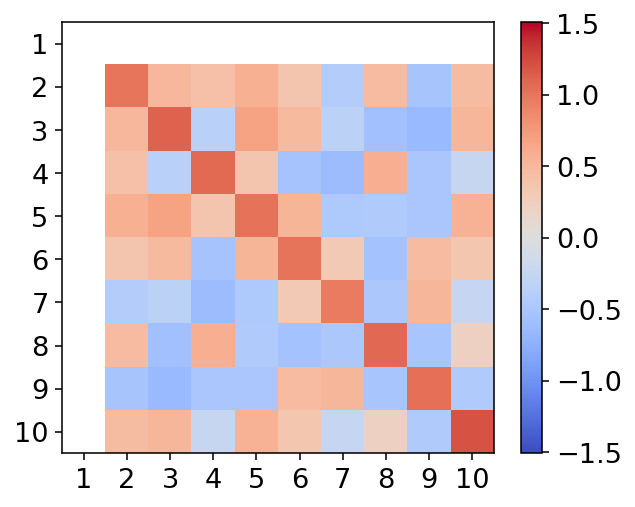

In [8]:
# seed  = torch.randint(0, 10000, (1,)).item()
seed = 9141
print(seed)
torch.manual_seed(seed)
dim = 10
sub_dim = dim - 1
# Create sub covariance
orthonormal = torch.linalg.qr(torch.randn(sub_dim, sub_dim))[0]
sub_cov = orthonormal @ torch.diag(torch.rand(sub_dim) + 0.5) @ orthonormal.T
# Create additional covariance
sub_cov2 = torch.zeros((dim, dim))
sub_cov2[:sub_dim,:][:, :sub_dim] = sub_cov
sub_cov2[sub_dim, sub_dim] = sub_cov[0,0]

A = torch.eye(dim)
A[sub_dim,0] = 0.5
A[sub_dim,sub_dim] = 0.5

cov = A @ sub_cov2 @ A.T
# Make mean and update dim
mean = torch.zeros(dim) + 0.5


prec = torch.inverse(cov)
our_normal = dists.MultivariateNormal(mean, cov)
gen_norm = dists.Normal(0, 4)
missing_prob = 0.2

print(prec)
prec_squish = np.cbrt(prec.numpy())
# Plot covariance and precision matrix
fig, ax = plt.subplots(figsize=(5, 4))
cax0 = ax.imshow(cov, cmap='coolwarm', vmin=-np.max(np.abs(cov.numpy())), vmax=np.max(np.abs(cov.numpy())))
ax.set_xticks(np.arange(cov.shape[0]))
ax.set_xticklabels(np.arange(1, cov.shape[0] + 1), fontsize=14)
ax.set_yticks(np.arange(cov.shape[1]))
ax.set_yticklabels(np.arange(1, cov.shape[0] + 1), fontsize=14)
cbar = fig.colorbar(cax0, ax=ax)
cbar.ax.tick_params(labelsize=14)
fig.savefig("../plots/NormalEstimation/NormalCovariance.pdf")

fig, ax = plt.subplots(figsize=(5, 4))
cax1 = ax.imshow(prec, cmap='coolwarm', vmin=-np.max(np.abs(prec.numpy())), vmax=np.max(np.abs(prec.numpy())))
cbar = fig.colorbar(cax1, ax=ax)
cbar.ax.tick_params(labelsize=14)
ax.set_xticks(np.arange(prec_squish.shape[0]))
ax.set_xticklabels(np.arange(1, cov.shape[0] + 1), fontsize=14)
ax.set_yticks(np.arange(prec_squish.shape[1]))
ax.set_yticklabels(np.arange(1, cov.shape[0] + 1), fontsize=14)
fig.savefig("../plots/NormalEstimation/NormalPrecision.pdf")

naive_marge = torch.nan*torch.ones(dim,dim)
naive_marge[1:,:][:,1:] = prec[1:, :][:, 1:]
naive_marge_squish = np.cbrt(naive_marge.numpy())

true_marg = torch.nan*torch.ones(dim,dim)
true_marg[1:, :][:, 1:] = torch.inverse(cov[1:, :][:, 1:])
true_marg_squish = np.cbrt(true_marg.numpy())
vlim = np.nanmax(np.abs(np.concatenate((naive_marge_squish.flatten(),true_marg_squish.flatten()))))

fig, ax = plt.subplots(figsize=(5, 4))
cax0 = ax.imshow(naive_marge_squish, cmap='coolwarm', vmin=-vlim, vmax=vlim)
cbar = fig.colorbar(cax0, ax=ax)
cbar.ax.tick_params(labelsize=14)
ax.set_xticks(np.arange(naive_marge_squish.shape[0]))
ax.set_yticks(np.arange(naive_marge_squish.shape[1]))
ax.set_xticklabels(np.arange(1, cov.shape[0] + 1), fontsize=14)
ax.set_yticklabels(np.arange(1, cov.shape[1] + 1), fontsize=14)
fig.savefig("../plots/NormalEstimation/NormalNaiveMarginalisation.pdf")

fig, ax = plt.subplots(figsize=(5, 4))
cax1 = ax.imshow(true_marg_squish, cmap='coolwarm', vmin=-vlim, vmax=vlim)
cbar = fig.colorbar(cax1, ax=ax)
cbar.ax.tick_params(labelsize=14)
ax.set_xticks(np.arange(true_marg_squish.shape[0]))
ax.set_yticks(np.arange(true_marg_squish.shape[1]))
ax.set_xticklabels(np.arange(1, cov.shape[0] + 1), fontsize=14)
ax.set_yticklabels(np.arange(1, cov.shape[1] + 1), fontsize=14)
fig.savefig("../plots/NormalEstimation/NormalTrueMarginalisation.pdf")
